In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Neuron definitions

## Leaky Integrate-and-Fire (LIF)

The LIF neuron is the standard workhorse of spiking neural network models. It accumulates input over time (integrate), passively decays toward rest (leak), and emits a spike when the membrane potential crosses a threshold, after which it resets.

$$m[t+1] = \beta \cdot m[t] + w \cdot x[t] - s[t] \cdot \vartheta$$

$$s[t] = \begin{cases} 1 & \text{if } m[t] > \vartheta \\ 0 & \text{otherwise} \end{cases}$$

- $m$ — membrane potential
- $\beta \in [0, 1)$ — membrane decay factor (leak)
- $w$ — synaptic weight
- $x$ — input signal
- $\vartheta$ — firing threshold
- $s$ — spike output (0 or 1)

In [2]:
def LIF(mem, w, x, beta, threshold):
    spk = (mem > threshold)

    spk = spk.astype(float)

    mem = beta*mem + w*x - spk*threshold

    return mem, spk

## Adaptive Leaky Integrate-and-Fire (ALIF)

The ALIF extends the LIF with an adaptive threshold. Each spike causes the threshold to jump up by $\Delta\vartheta$, after which it decays back toward the baseline $\vartheta_0$. This makes the neuron progressively harder to fire in rapid succession, mimicking spike-frequency adaptation observed in biological neurons.

$$m[t+1] = \beta_m \cdot m[t] + w \cdot x[t] - s[t] \cdot \vartheta[t]$$

$$\vartheta[t+1] = \beta_\vartheta \cdot (\vartheta[t] - \vartheta_0) + \vartheta_0 + s[t] \cdot \Delta\vartheta$$

$$s[t] = \begin{cases} 1 & \text{if } m[t] > \vartheta[t] \\ 0 & \text{otherwise} \end{cases}$$

- $m$ — membrane potential
- $\beta_m \in [0, 1)$ — membrane decay factor
- $\beta_\vartheta \in [0, 1)$ — threshold decay factor
- $w$ — synaptic weight
- $x$ — input signal
- $\vartheta$ — adaptive firing threshold
- $\vartheta_0$ — baseline threshold
- $\Delta\vartheta$ — threshold increment on spike
- $s$ — spike output (0 or 1)

In [3]:
def ALIF(mem, thr, w, x, beta_mem, beta_thr, thr_base, thr_inc):
    
    spk = (mem > thr)
    spk = spk.astype(float)
    
    mem = beta_mem * mem + w * x - spk * thr
    
    thr = beta_thr * (thr - thr_base) + thr_base + spk * thr_inc
    
    return mem, spk, thr

In [4]:
# define all the constants

delta_t = np.array(1e-3)
tau = np.array(5e-3) 
mem_beta = np.exp(-delta_t/tau) # = 0.8187

thr = np.array(1.0)
th_beta = np.array(0.99)
th_base = np.array(1.0)
th_inc = np.array(0.1)

w = 0.4

print(f"The decay rate is: {mem_beta:.3f}")
print(f"The threshold beta is: {th_beta:.3f}")

The decay rate is: 0.819
The threshold beta is: 0.990


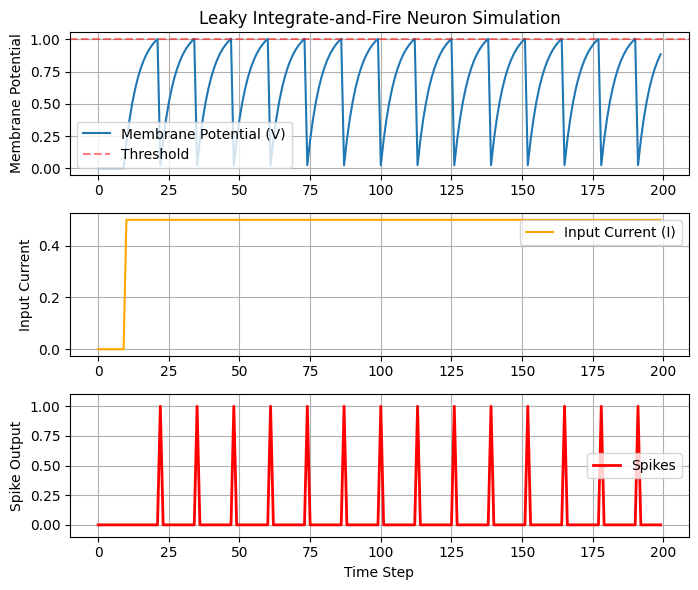

In [5]:
num_steps = 200


# initialize inputs/outputs + small step current input
# replace this line with a numpy version
x = np.concatenate((np.zeros(10), np.ones(190)*0.5))


mem = np.zeros(1)
spk = np.zeros(1)
mem_rec = []
spk_rec = []

# neuron simulation
for step in range(num_steps):
  mem, spk = LIF(mem=mem, x=x[step], w=w, beta=mem_beta, threshold=thr) 
  mem_rec.append(mem)
  spk_rec.append(spk)

# convert lists to tensors
mem_rec = np.array(mem_rec)
spk_rec = np.array(spk_rec)

time = range(num_steps)

# plot V, I, and spikes
plt.figure(figsize=(7, 6))

plt.subplot(3, 1, 1)
plt.plot(time, mem_rec, label='Membrane Potential (V)')
plt.axhline(y=thr, color='r', linestyle='--', alpha=0.5, label='Threshold')
plt.title('Leaky Integrate-and-Fire Neuron Simulation')
plt.ylabel('Membrane Potential')
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(time, x, label='Input Current (I)', color='orange')
plt.ylabel('Input Current')
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(time, spk_rec, 'r', linewidth=2, label='Spikes')
plt.ylabel('Spike Output')
plt.xlabel('Time Step')
plt.ylim([-0.1, 1.1])
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


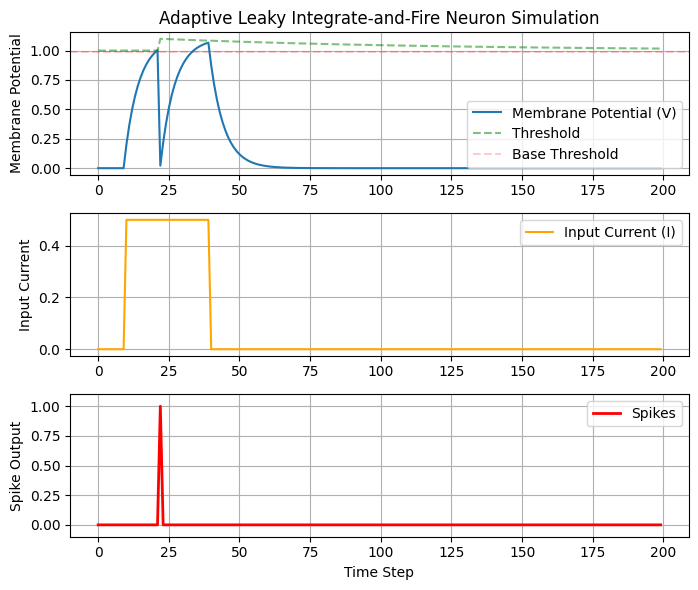

In [6]:
num_steps = 200

x = np.concatenate((np.zeros(10), np.ones(30)*0.5, np.zeros(160)))


mem = np.zeros(1)
spk = np.zeros(1)
thr = np.ones(1)
mem_rec = []
spk_rec = []
thr_rec = []

# neuron simulation
for step in range(num_steps):
  mem, spk, thr = ALIF(mem=mem, thr=thr, x=x[step], w=w, beta_mem=mem_beta, beta_thr=th_beta, thr_base=th_base, thr_inc=th_inc)
  thr_rec.append(thr)
  mem_rec.append(mem)
  spk_rec.append(spk)

# convert lists to tensors
mem_rec = np.array(mem_rec)
spk_rec = np.array(spk_rec)
thr_rec = np.array(thr_rec)


time = range(num_steps)

plt.figure(figsize=(7, 6))

plt.subplot(3, 1, 1)
plt.plot(time, mem_rec, label='Membrane Potential (V)')
plt.plot(time, thr_rec, label='Threshold', color='green', linestyle='--', alpha=0.5) 
plt.axhline(y=th_beta, color='r', linestyle='--', alpha=0.2, label='Base Threshold')
plt.title('Adaptive Leaky Integrate-and-Fire Neuron Simulation')
plt.ylabel('Membrane Potential')
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(time, x, label='Input Current (I)', color='orange')
plt.ylabel('Input Current')
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(time, spk_rec, 'r', linewidth=2, label='Spikes')
plt.ylabel('Spike Output')
plt.xlabel('Time Step')
plt.ylim([-0.1, 1.1])
plt.legend()
plt.grid()



plt.tight_layout()
plt.show()
